# High-Density High-Order Kuramoto Oscillator Network for Sequential Associative memory

We consider a smooth-evolution case where sequence members are mutations from original pattern.

## Questions:


1) For given N, what L length produces a tolerant retrieval rate for a **single sequence**

2) For given N, what L produces a tolerant retrieval rate for **M indepndent sequences**

3) Investigate a crossing sequence for associative memory between 2 sequences

4) Does last index in markov-chain update rule reference itself or cycle through

5) Hidden Variables, implemented as additional neurons outside the pattern image (possibly)





## Model (Update Rule and OverLap):

This notebook tests d=3 high-order Kuramoto-type oscillator network 

$$\dot{\theta}_i
=
-\sin\theta_i
\sum_{\mu=1}^{P}
\xi_i^{\mu+1}
\left(
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^\mu
\cos\theta_j
\right)^d$$

Synchronise into binary because of high order d (want the phases to converge to binary in the end)

The sequence is a single chain of period $P$ with a terminal self-loop, $\xi^{P+1}
\equiv \xi^{P}$ (the last pattern points to itself rather than wrapping back to $\xi^1$),
so once the dynamics reach the last pattern they settle there instead of cycling
indefinitely.



For memory $\mu$, define the **overlap** of state with some pattern as

$$m_i^\mu(\boldsymbol{\theta})
=
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^\mu
\cos\theta_j$$

Zero overlap means half the spins are opposite; overlap 1 means total allignment; **Overlap is the order parameter = macroscopic; some information is lost**




## Implementation:

- For a given pattern, we mutate it in accordance with some rand seed to make up a sequence.

- Gradient descent is achieved via either ODE EULER or SDE (Stochastic) Euler-Maruyama time evol.

- The sequence is tracked with an online sequence tracker for overlap with stored patterns during gradient descent; tolerance set to 80 percent AND we arg max is required; strict order, meaning break traverse if encountering incorrect pattern / element

- Trials run for 20 seeds, 20 times per seed

- Classes and methods implemented in **kuramoto_library2.py**

- Here we will retain self-referencing for last pattern

- Success calculated as $L_{max}(N)$: averaged out over 20 generation seeds

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import kuramoto_library2 as krm

import matplotlib.pyplot as plt

In [2]:
CONFIG = dict(
    dt=0.5,  # integration timestep for the dynamical evolution
    T=45.0,  # total simulation time
    frequency_std=0.03,  # heterogeneity in intrinsic frequencies, adding disorder to retrieval dynamics
    phase_noise=0.01,  # stochastic phase perturbations during evolution (SDE mode only)
    d=3,  # order (polynomial degree) of the high-order Kuramoto / dense associative memory coupling
    corruption_rate=0.2,  # fraction of neurons flipped in the cue used to initialize theta
    tolerance = 0.5,  # threshold for determining whether a pattern is successfully retrieved based on overlap peak
    mode="ode",  # 'ode' (deterministic Forward Euler) or 'sde' (Euler-Maruyama with phase noise)
)

SWEEP_CONFIG = dict(
    retrieval_tolerance=0.9,  # target strict-decode retrieval fraction for the L(N) sweep
    retrieval_tolerance_margin=0.05,  # +/- sweep margin around retrieval_tolerance for the upper/lower bound curves
    persistence_window=3,  # consecutive L values the retrieval fraction must stay <= tolerance for,
                           # so an isolated one-off failure isn't mistaken for the real L_max (see 1.3)
    sticky_margin=0.01,  # margin for the "sticky" online decoding
)

# 1. Single Sequence retrieval

## 1.1 Generating a sequence by mutation

Instead of drawing $P$ independent random patterns, we generate one base pattern $A$ and
build the sequence by repeatedly mutating it: $\xi^{k+1}$ is obtained from $\xi^{k}$ by
corrupting it at `CONFIG["corruption_rate"]` -- the same flip-a-random-subset-of-spins
operation already used to build a cue, just applied to grow the sequence instead of a
one-off retrieval test. So each element is correlated with its predecessor, and the
Hamming distance from $A$ grows (roughly) with $k$ -- this is the "smooth-evolution"
sequence described above, as opposed to a chain of unrelated codes.

In [3]:
N = 40
seq_len = 8   # sequence length (excluding the base pattern because we descend into sequence)
seed = 10        # single-trial demo seed

net = krm.KuramotoNetwork(N=N, seed=seed, **CONFIG)

A = net.generate_sequence(
    name="A",
    seq_len=seq_len,
    corruption_rate=CONFIG["corruption_rate"],
    seed=seed,
)
A

<Sequence 'A' | <VectorSequence [Pre-allocated] | Length: 9, Dim: 40>>

In [4]:
xi_seq = A.xi()

hamming_from_base = ((xi_seq[1:] != xi_seq[0]).sum(axis=1))
hamming_consecutive = ((xi_seq[1:] != xi_seq[:-1]).sum(axis=1))

print("Sequence:", A)
print("Hamming distance from base A:      ", hamming_from_base)
print("Hamming distance consecutive steps:", hamming_consecutive)

Sequence: <Sequence 'A' | <VectorSequence [Pre-allocated] | Length: 9, Dim: 40>>
Hamming distance from base A:       [ 8 10 10 18 20 22 18 20]
Hamming distance consecutive steps: [8 8 8 8 8 8 8 8]


## 1.2 Different sequences for different random seeds

The seed controls both the base pattern $A$ (drawn by `generate_sequence`) and the
mutation draws at each step, so different seeds give genuinely different sequences, not
just different corruption noise on top of the same one. Build one network per seed,
simulate, and plot the pattern overlaps for each.

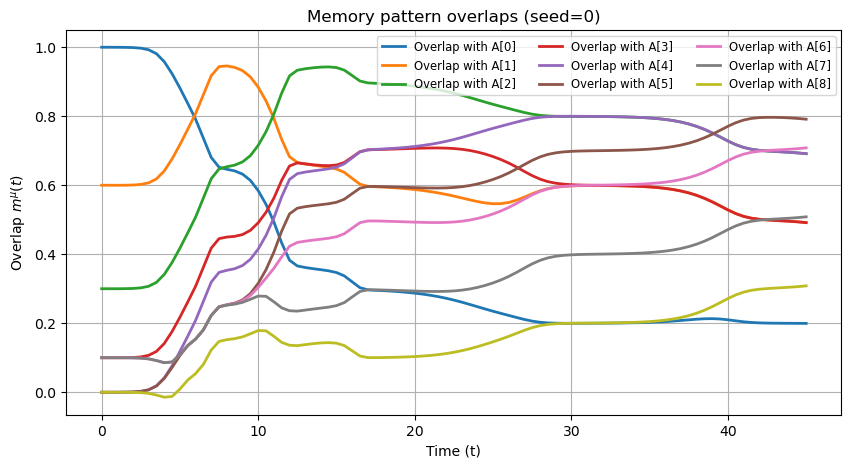

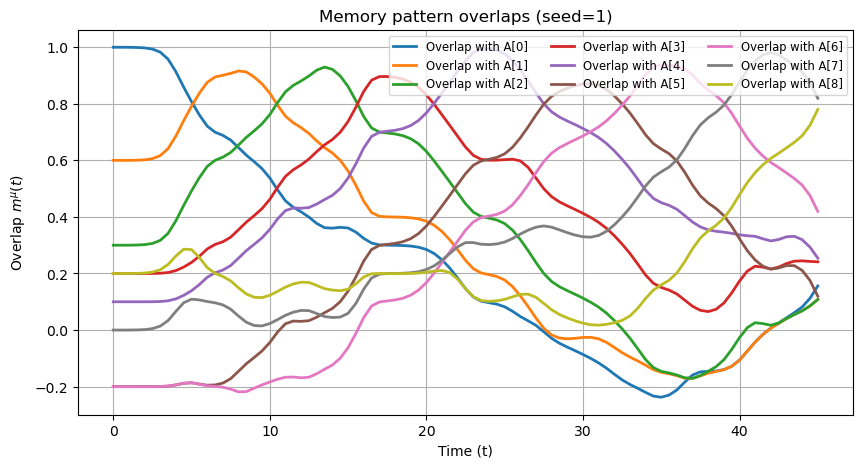

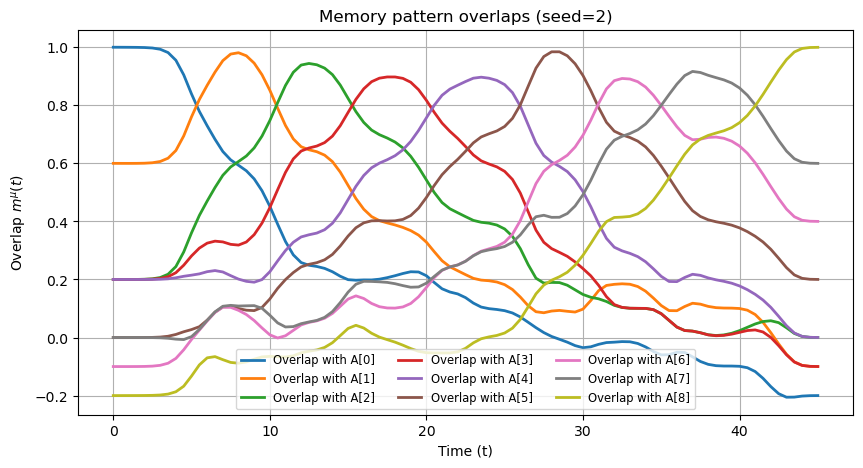

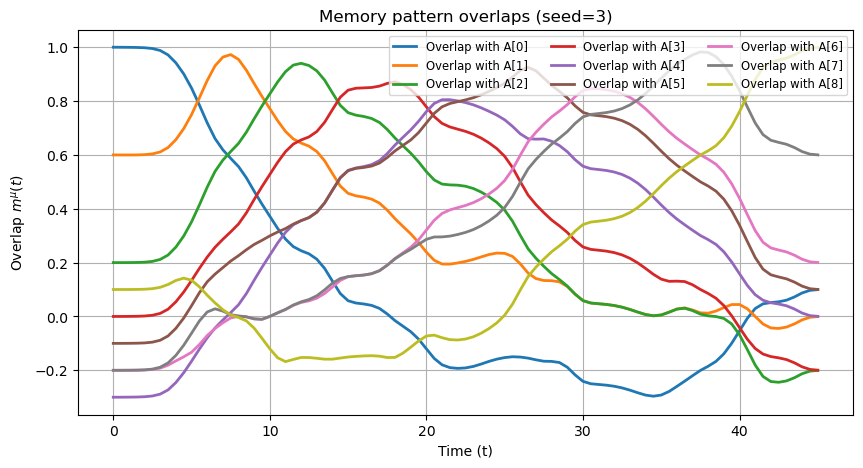

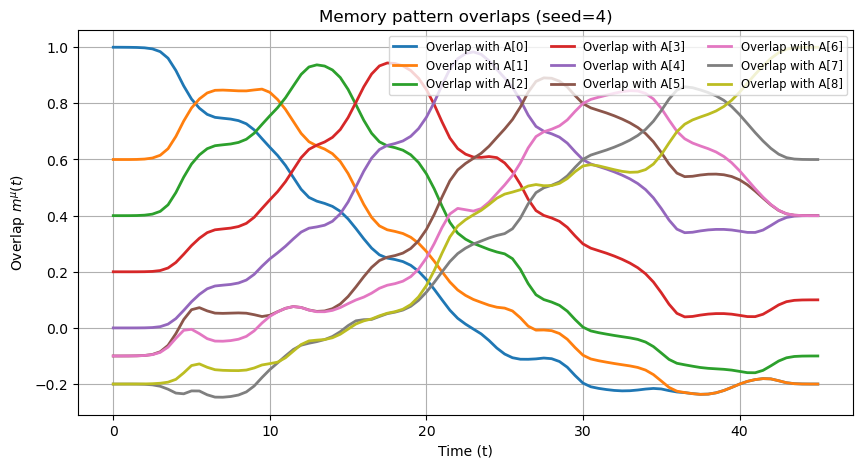

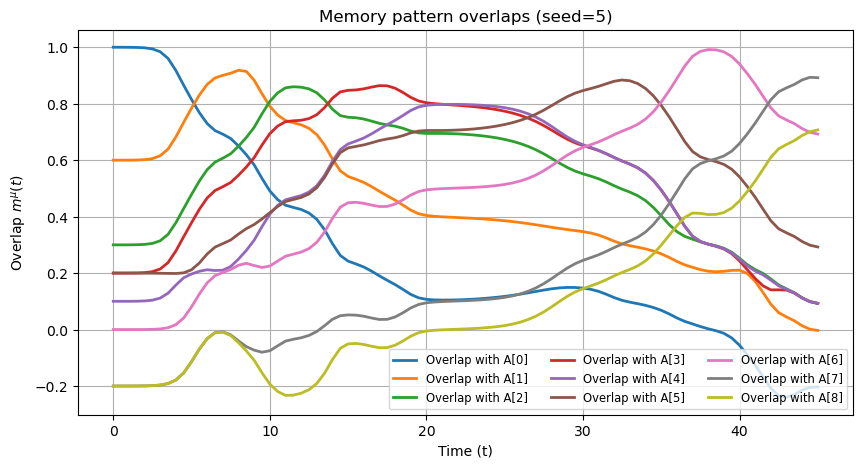

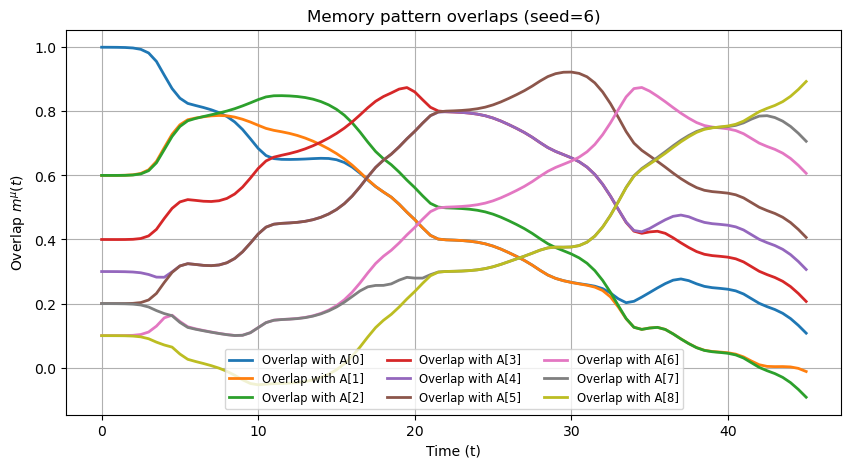

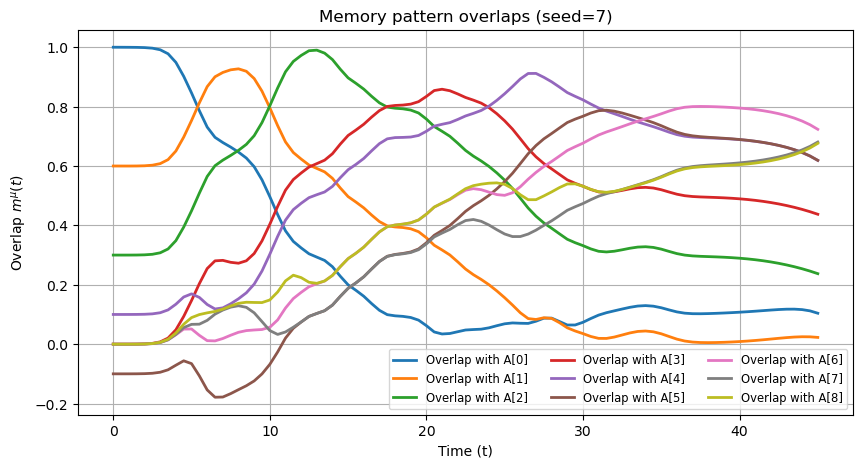

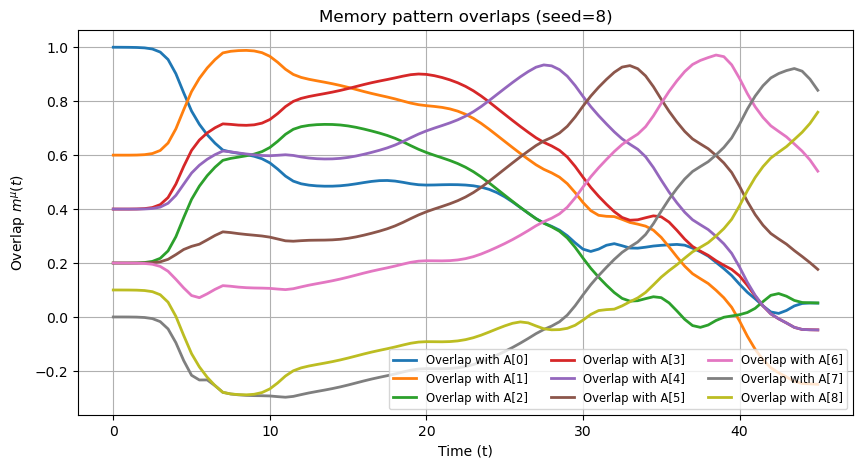

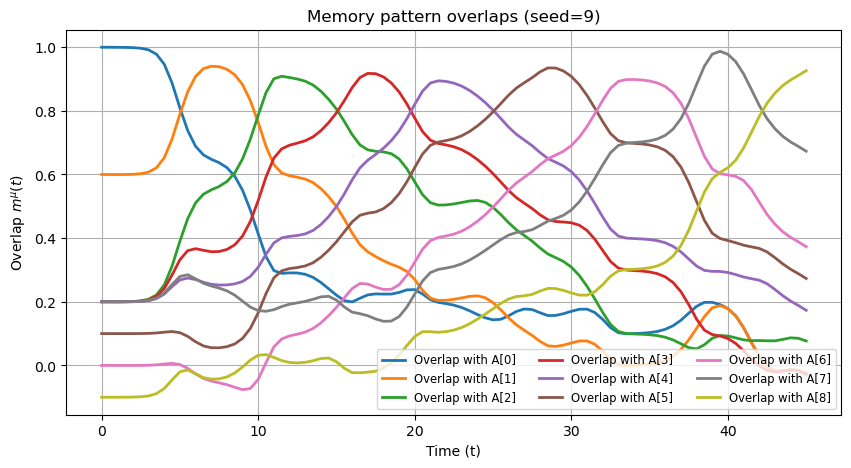

In [5]:
SEEDS = list(range(10)) 
for seed in SEEDS:
    seed_net = krm.KuramotoNetwork(N=N, seed=seed, **CONFIG)
    seed_A = seed_net.generate_sequence(
        name="A",
        seq_len=seq_len,
        corruption_rate=CONFIG["corruption_rate"],
        seed=seed,
    )
    result = seed_net.simulate(seed_A)
    seed_net.plot(result, seed_A, title=f"Memory pattern overlaps (seed={seed})")

## 1.3 $L$(N): for given N, what L produces a 90% retrieval rate?

Instead of employing scipy.find_peaks(), need to create a list of subsequent top overlap values (and then compress by removing repeating indices = that is the retrieved sequence).

In [6]:
def _fraction_at_L(N, seed, L):
    """Strict-decode retrieval fraction for one (seed, L) trial: generate a fresh
    length-L sequence (L patterns), simulate it, decode it, and compare against
    the stored ground truth. L's time budget is scaled from the single-trial
    demo in 1.1 (T=CONFIG["T"] for an 8-element chain) so longer chains aren't
    starved of integration time."""
    time_per_element = CONFIG["T"] / 8
    trial_T = time_per_element * L
    seq = krm.generate_sequence(N, seq_len=L - 1, corruption_rate=CONFIG["corruption_rate"], seed=seed)
    net = krm.KuramotoNetwork(N=N, seed=seed, **CONFIG)
    result = net.simulate(seq, T=trial_T)
    retrieved = net.decode_sequence_online(result, seq, margin=SWEEP_CONFIG["sticky_margin"], tolerance=CONFIG["tolerance"])
    fail_step = net.compare_to_stored_sequence(retrieved, seq)
    return fail_step / L


def _seed_fraction_cache(N, seed):
    """Memoized fraction(L) function for one seed. Searching for several different
    tolerance thresholds against the same seed (see `run_loop` and the sweep
    below) ends up re-visiting some of the same L values -- this cache means
    each (seed, L) trial is only ever simulated once, no matter how many
    thresholds it's checked against."""
    cache = {}
    def fraction(L):
        if L not in cache:
            cache[L] = _fraction_at_L(N, seed, L)
        return cache[L]
    return fraction


def _is_persistent_failure(fraction, tolerance, L, window):
    """True if the retrieval fraction stays <= tolerance for `window` consecutive
    L values starting at L -- a sustained failure, not a one-off blip. Real
    fraction(L) curves aren't strictly decreasing: an isolated bad trial can dip
    below tolerance and then recover to perfect retrieval a few L later, before
    degrading for good much further out. Requiring a run of `window` consecutive
    failures filters that out. `all(...)` short-circuits at the first L that
    doesn't fail, so this doesn't pay for the full window when L clearly isn't
    a persistent failure."""
    return all(fraction(L + k) <= tolerance for k in range(window))


def _find_persistent_L(tolerance, fraction, window=SWEEP_CONFIG["persistence_window"]):
    """Smallest L >= 1 at which retrieval fails *persistently* (see
    `_is_persistent_failure`), found via exponential + binary search on that
    persistence predicate rather than raw fraction(L) -- raw fraction(L) isn't
    monotonic (see above), but "the next `window` values are all a failure" is:
    once a persistent-failure region starts, it stays true for every L further
    into it, which is exactly what exponential/binary search needs to work.

    Exponential search doubles L until it brackets a persistent failure, then
    binary search pins down the exact smallest such L -- O(window x log L)
    evaluations of `fraction` (cached, so cheap) instead of a linear L=1,2,3,...
    scan all the way out to L_max.
    """
    lo = hi = 1
    while not _is_persistent_failure(fraction, tolerance, hi, window):
        lo = hi
        hi *= 2

    while lo < hi - 1:
        mid = (lo + hi) // 2
        if _is_persistent_failure(fraction, tolerance, mid, window):
            hi = mid
        else:
            lo = mid
    return hi


def run_loop(N, tolerance, seed_range):
    """For network size N, return the average sequence length L_max at which the
    strict-decode retrieval fraction fails *persistently* (see
    `_is_persistent_failure`), averaged over `seed_range` generation seeds --
    matching section 1's stated success metric, "L_max(N): averaged out over 20
    generation seeds" (1.3). Generally not an integer, since it's a mean over
    seeds of each seed's own (integer) L_max.

    For each seed independently, `_find_persistent_L` searches for that seed's
    own L_max via exponential + binary search rather than incrementing L one at
    a time, and `_seed_fraction_cache` memoizes each (seed, L) trial actually
    simulated.
    """
    lmaxes = [_find_persistent_L(tolerance, _seed_fraction_cache(N, seed)) for seed in range(seed_range)]
    return sum(lmaxes) / len(lmaxes)

In [ ]:
# could optimise the computation by parallelisation

# tolerance here is the fraction of the sequence length that must be retrieved
# correctly (strict decoding), not the overlap threshold -- that's CONFIG["tolerance"]

seed_range = 20

data_points = []
upper_tolerance = []
lower_tolerance = []
for N in range(0, 501, 50):
    # Each tolerance threshold is run as its own separate, independent search --
    # not sharing simulated trajectories across thresholds.
    avg_lmax = run_loop(N, tolerance=SWEEP_CONFIG["retrieval_tolerance"], seed_range=seed_range)
    print(f"N={N}, avg_lmax={avg_lmax}")
    data_points.append((N, avg_lmax))

    upper_tolerance.append((N, run_loop(N, tolerance=SWEEP_CONFIG["retrieval_tolerance"] + SWEEP_CONFIG["retrieval_tolerance_margin"], seed_range=seed_range)))
    lower_tolerance.append((N, run_loop(N, tolerance=SWEEP_CONFIG["retrieval_tolerance"] - SWEEP_CONFIG["retrieval_tolerance_margin"], seed_range=seed_range)))


Ns, centers = zip(*data_points)
_, uppers = zip(*upper_tolerance)
_, lowers = zip(*lower_tolerance)

centers = np.array(centers)
uppers = np.array(uppers)
lowers = np.array(lowers)


err_low = np.clip(centers - uppers, 0, None)
err_high = np.clip(lowers - centers, 0, None)

plt.errorbar(
    Ns, centers, yerr=[err_low, err_high],
    marker='o', color='blue', ecolor='gray', capsize=4, linestyle='none',
)

# Add basic labels
plt.title(f"Simulation Results, tolerance={SWEEP_CONFIG['retrieval_tolerance']}")
plt.xlabel("N, network size")
plt.ylabel(r"Average $L_{max}$")
plt.grid(True)

# Show the graph
plt.show()

# zero just provides a sanity check

N=0, avg_lmax=2.0


N=50, avg_lmax=28.1
N=100, avg_lmax=159.0
N=150, avg_lmax=1273.05


# 2. Multiple Sequence Retrieval